In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị cho matplotlib/seaborn
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đường dẫn tới file parquet
parquet_path = "../data/EnterpriseRAG-Bench/data/documents/test.parquet"

In [2]:
try:
    df = pd.read_parquet(parquet_path)
    print(f"✅ Đã tải thành công: {len(df):,} dòng (documents)")
except Exception as e:
    print(f"❌ Lỗi khi đọc file: {e}")
    print("Vui lòng cài đặt thư viện: pip install pandas pyarrow matplotlib seaborn")

✅ Đã tải thành công: 511,962 dòng (documents)


In [3]:
display(df.head())

,doc_id,source_type,title,content
0,dsid_e54ef48bae78474684a957cf613d47d5,confluence,Runbook: Deploy / Upgrade / Roll Back perf-can...,## Purpose\nThis runbook describes the operati...
1,dsid_229dd48e9b1d466a81ebaffe3ec84469,confluence,Cross-account GPU burst SLO contract and CI li...,Summary\n\nOverview:\nThis document defines th...
2,dsid_aeb0022d62bc43beb6549ba92e5655eb,confluence,Third-Party & Vendor Coordination Playbook for...,Overview\n\nPurpose:\nThis playbook documents ...
3,dsid_926174fc4900408c89c98abde46b7225,confluence,First Production Launch Checklist (Canonical T...,## Purpose\nThis page defines the **canonical ...
4,dsid_d511c6d8daf94f998ce6a3d97462af2d,confluence,Go-Live Runway and Week-3 Stability Playbook,Overview\n\nThis playbook defines the technica...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511962 entries, 0 to 511961
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   doc_id       511962 non-null  object
 1   source_type  511962 non-null  object
 2   title        511962 non-null  object
 3   content      511962 non-null  object
dtypes: object(4)
memory usage: 15.6+ MB


In [5]:
missing_data = df.isnull().sum()
print("Số lượng missing values mỗi cột:")
print(missing_data[missing_data > 0])

Số lượng missing values mỗi cột:
Series([], dtype: int64)


/tmp/ipykernel_249668/30962506.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.values, y=source_counts.index, palette="viridis")


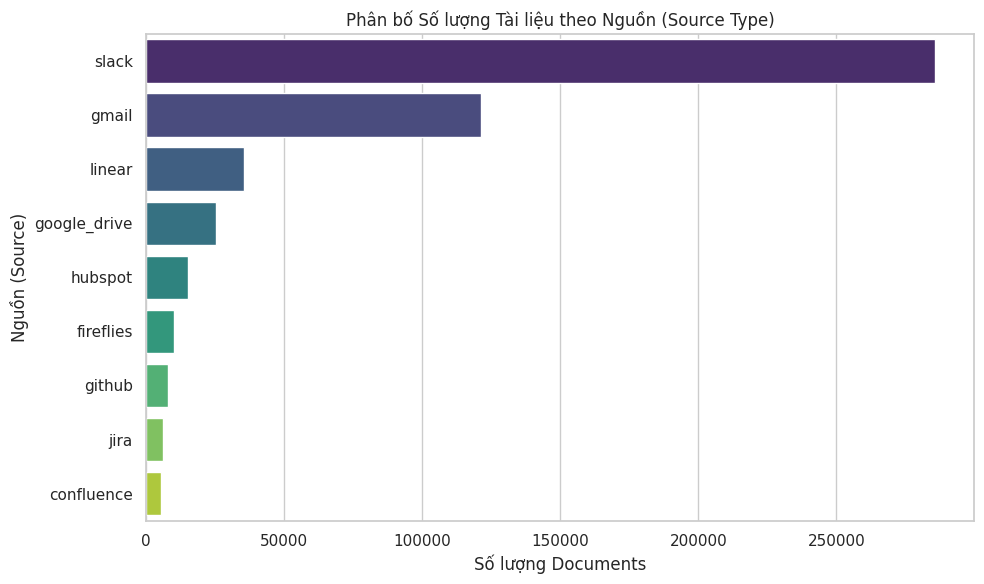

In [6]:
if 'source' in df.columns:  # Hoặc 'source_type' tùy vào cấu trúc dataset
    source_col = 'source'
elif 'source_type' in df.columns:
    source_col = 'source_type'
else:
    source_col = None

if source_col:
    source_counts = df[source_col].value_counts()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=source_counts.values, y=source_counts.index, palette="viridis")
    plt.title("Phân bố Số lượng Tài liệu theo Nguồn (Source Type)")
    plt.xlabel("Số lượng Documents")
    plt.ylabel("Nguồn (Source)")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy cột 'source' hoặc 'source_type'")

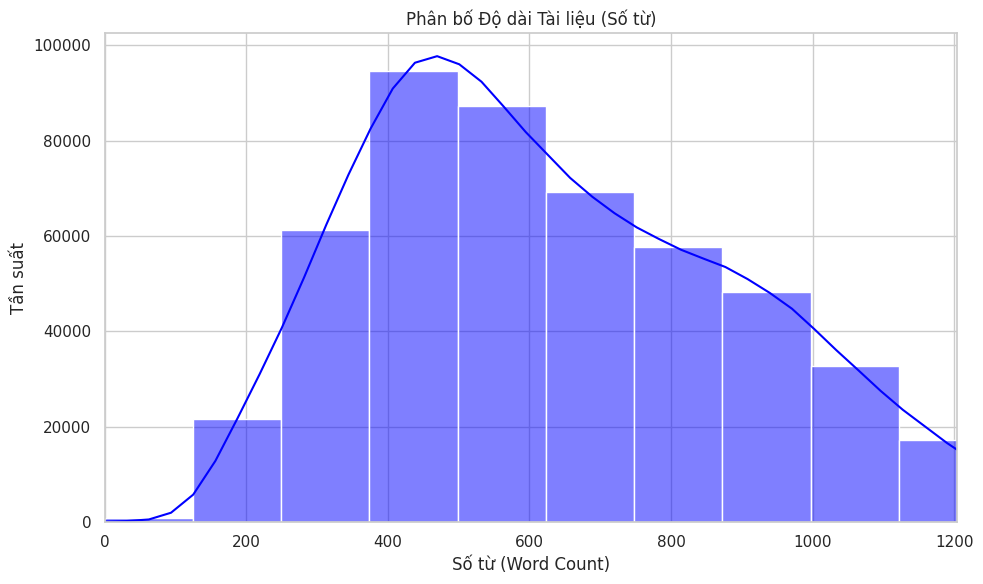

Thống kê mô tả độ dài tài liệu:
count    511962.000000
mean        667.398688
std         327.614426
min           0.000000
25%         434.000000
50%         607.000000
75%         853.000000
max        6230.000000
Name: word_count, dtype: float64


In [7]:
if 'text' in df.columns or 'content' in df.columns:
    text_col = 'text' if 'text' in df.columns else 'content'
    
    # Tính số lượng từ (words) ước tính
    df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df['word_count'], bins=50, kde=True, color='blue')
    plt.title("Phân bố Độ dài Tài liệu (Số từ)")
    plt.xlabel("Số từ (Word Count)")
    plt.ylabel("Tần suất")
    plt.xlim(0, df['word_count'].quantile(0.95)) # Cắt bỏ 5% outliers dài nhất để dễ nhìn
    plt.tight_layout()
    plt.show()
    
    print("Thống kê mô tả độ dài tài liệu:")
    print(df['word_count'].describe())

In [8]:
time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]

if time_cols:
    time_col = time_cols[0]
    print(f"Sử dụng cột thời gian: {time_col}")
    
    # Chuyển đổi sang datetime nếu chưa phải
    if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        try:
            df['parsed_date'] = pd.to_datetime(df[time_col], errors='coerce')
        except:
            df['parsed_date'] = pd.NaT
    else:
        df['parsed_date'] = df[time_col]
        
    # Xóa các dòng NaT để vẽ biểu đồ
    valid_dates = df['parsed_date'].dropna()
    
    if not valid_dates.empty:
        # Group theo năm-tháng
        monthly_counts = valid_dates.dt.to_period('M').value_counts().sort_index()
        
        plt.figure(figsize=(12, 6))
        monthly_counts.plot(kind='bar', color='coral')
        plt.title("Số lượng tài liệu theo Thời gian (Tháng)")
        plt.xlabel("Tháng")
        plt.ylabel("Số lượng")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("Không tìm thấy cột chứa thông tin thời gian.")

Không tìm thấy cột chứa thông tin thời gian.
